In [1]:
!pip install torch-pruning scipy tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
from torchvision.models import mobilenet_v2
from tqdm import tqdm
import numpy as np
import torch_pruning as tp
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE = 128
EPOCHS_PRETRAIN = 100
EPOCHS_FINETUNE = 100

PRUNE_RATIO = 0.2
CALIB_SAMPLES = 2000

LR = 0.01
WEIGHT_DECAY = 5e-4

torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)

Device: cuda


In [4]:
train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),
                (0.2470,0.2435,0.2616))
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914,0.4822,0.4465),
                (0.2470,0.2435,0.2616))
])

train_set = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_tf
)

test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=test_tf
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_set, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:02<00:00, 61.4MB/s]


In [5]:
model = mobilenet_v2(num_classes=10)

model.features[0][0] = nn.Conv2d(3, 32, 3, 1, 1, bias=False)
model.avgpool = nn.AdaptiveAvgPool2d((1,1))

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(1280, 100)
)

model = model.to(DEVICE)

In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(), lr=LR,
    momentum=0.9, weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[25,35], gamma=0.1)

train_acc, test_acc = [], []

In [7]:
def evaluate(model):
    model.eval()
    correct,total = 0,0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x).argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

In [8]:
best_acc = 0

print("Starting Pretraining...")

for epoch in range(EPOCHS_PRETRAIN):

    model.train()

    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = criterion(model(x),y)
        loss.backward()
        optimizer.step()

    scheduler.step()

    acc = evaluate(model)
    test_acc.append(acc)

    print(f"Epoch {epoch+1} | Acc {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(),
                   "/kaggle/working/mobilenetv2_baseline_best.pt")

Starting Pretraining...
Epoch 1 | Acc 45.68%
Epoch 2 | Acc 53.62%
Epoch 3 | Acc 57.89%
Epoch 4 | Acc 63.37%
Epoch 5 | Acc 65.16%
Epoch 6 | Acc 69.19%
Epoch 7 | Acc 70.19%
Epoch 8 | Acc 71.50%
Epoch 9 | Acc 72.90%
Epoch 10 | Acc 71.71%
Epoch 11 | Acc 77.04%
Epoch 12 | Acc 77.09%
Epoch 13 | Acc 78.29%
Epoch 14 | Acc 78.40%
Epoch 15 | Acc 80.23%
Epoch 16 | Acc 79.88%
Epoch 17 | Acc 80.91%
Epoch 18 | Acc 81.59%
Epoch 19 | Acc 81.72%
Epoch 20 | Acc 81.49%
Epoch 21 | Acc 80.83%
Epoch 22 | Acc 82.85%
Epoch 23 | Acc 82.23%
Epoch 24 | Acc 82.93%
Epoch 25 | Acc 80.73%
Epoch 26 | Acc 85.88%
Epoch 27 | Acc 86.28%
Epoch 28 | Acc 86.44%
Epoch 29 | Acc 86.18%
Epoch 30 | Acc 86.45%
Epoch 31 | Acc 86.55%
Epoch 32 | Acc 86.91%
Epoch 33 | Acc 86.34%
Epoch 34 | Acc 86.61%
Epoch 35 | Acc 86.36%
Epoch 36 | Acc 86.54%
Epoch 37 | Acc 86.65%
Epoch 38 | Acc 86.62%
Epoch 39 | Acc 86.59%
Epoch 40 | Acc 86.57%
Epoch 41 | Acc 86.69%
Epoch 42 | Acc 86.62%
Epoch 43 | Acc 86.62%
Epoch 44 | Acc 86.57%
Epoch 45 | Acc 86

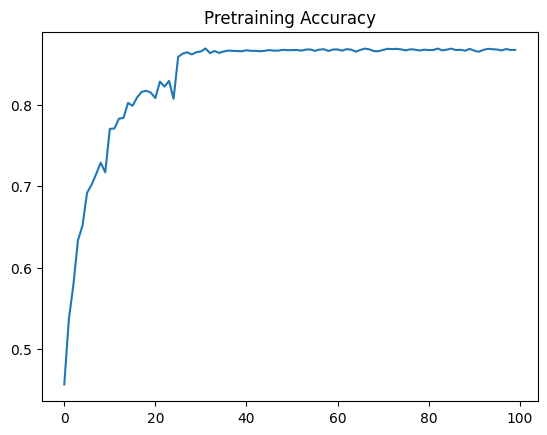

In [9]:
plt.plot(test_acc)
plt.title("Pretraining Accuracy")
plt.show()

In [10]:
idx = torch.randperm(len(train_set))[:CALIB_SAMPLES]
calib_loader = DataLoader(Subset(train_set, idx), batch_size=64)

activations = {}
gradients = {}

def fwd_hook(name):
    def hook(m,i,o): activations[name] = o.detach()
    return hook

def bwd_hook(name):
    def hook(m,gi,go): gradients[name] = go[0].detach()
    return hook

for name,m in model.named_modules():
    if isinstance(m, nn.Conv2d):
        m.register_forward_hook(fwd_hook(name))
        m.register_full_backward_hook(bwd_hook(name))

In [11]:
taylor = {}

model.eval()

print("Calculating Importance...")

for x,y in tqdm(calib_loader):
    x,y = x.to(DEVICE), y.to(DEVICE)

    loss = criterion(model(x),y)

    model.zero_grad()
    loss.backward()

    for k in activations:
        score = torch.abs(activations[k]*gradients[k]).sum((2,3))
        taylor.setdefault(k,[]).append(score.cpu())

taylor_final = {k: torch.cat(v).mean(0) for k,v in taylor.items()}

Calculating Importance...


100%|██████████| 32/32 [00:02<00:00, 11.66it/s]


In [12]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

params_before = count_params(model)

print("Parameters BEFORE pruning:", params_before)

Parameters BEFORE pruning: 2351972


In [13]:
def prune_structural(model, importance_dict):
    model = copy.deepcopy(model).to(DEVICE)
    model.eval()

    example_inputs = torch.randn(1,3,32,32).to(DEVICE)

    DG = tp.DependencyGraph().build_dependency(
        model, example_inputs=example_inputs
    )

    for name, module in model.named_modules():

        # Skip depthwise convs
        if isinstance(module, nn.Conv2d) and module.groups == module.out_channels:
            continue

        if isinstance(module, nn.Conv2d) and name in importance_dict:

            imp = importance_dict[name].to(DEVICE)
            imp = imp / (imp.sum() + 1e-8)

            keep = int(module.out_channels * (1 - PRUNE_RATIO))
            prune = module.out_channels - keep

            if prune <= 0:
                continue

            idx = torch.argsort(imp)[:prune].tolist()

            group = DG.get_pruning_group(
                module,
                tp.prune_conv_out_channels,
                idxs=idx
            )

            if DG.check_pruning_group(group):
                group.prune()

    return model

In [14]:
pruned_model = prune_structural(model, taylor_final)

print("Before pruning:", evaluate(model)*100)
print("After pruning :", evaluate(pruned_model)*100)

torch.save(pruned_model.state_dict(),
           "/kaggle/working/mobilenetv2_pruned_initial.pt")

Before pruning: 86.74
After pruning : 10.0


In [15]:
params_after = count_params(pruned_model)

print("Parameters AFTER pruning:", params_after)

compression = (1 - params_after / params_before) * 100

print(f"Compression: {compression:.2f}%")

Parameters AFTER pruning: 1234165
Compression: 47.53%


In [16]:
optimizer = torch.optim.SGD(
    pruned_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_FINETUNE
)

In [17]:
for param in pruned_model.features.parameters():
    param.requires_grad = False

for epoch in range(2):
    pruned_model.train()
    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = criterion(pruned_model(x),y)
        loss.backward()
        optimizer.step()

    print(f"Warmup Epoch {epoch+1} | Acc {evaluate(pruned_model)*100:.2f}%")

Warmup Epoch 1 | Acc 38.49%
Warmup Epoch 2 | Acc 40.77%


In [18]:
for param in pruned_model.parameters():
    param.requires_grad = True

best_acc = 0

for epoch in range(EPOCHS_FINETUNE):

    pruned_model.train()

    for x,y in train_loader:
        x,y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        loss = criterion(pruned_model(x),y)
        loss.backward()
        optimizer.step()

    scheduler.step()

    acc = evaluate(pruned_model)

    print(f"Epoch {epoch+1} | Acc {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        torch.save(pruned_model.state_dict(),
                   "/kaggle/working/mobilenetv2_pruned_best.pt")

Epoch 1 | Acc 73.57%
Epoch 2 | Acc 77.35%
Epoch 3 | Acc 79.27%
Epoch 4 | Acc 80.10%
Epoch 5 | Acc 81.03%
Epoch 6 | Acc 80.22%
Epoch 7 | Acc 81.34%
Epoch 8 | Acc 82.54%
Epoch 9 | Acc 83.26%
Epoch 10 | Acc 81.71%
Epoch 11 | Acc 82.13%
Epoch 12 | Acc 84.02%
Epoch 13 | Acc 83.86%
Epoch 14 | Acc 83.52%
Epoch 15 | Acc 84.55%
Epoch 16 | Acc 83.19%
Epoch 17 | Acc 84.89%
Epoch 18 | Acc 83.17%
Epoch 19 | Acc 85.10%
Epoch 20 | Acc 84.99%
Epoch 21 | Acc 84.89%
Epoch 22 | Acc 85.30%
Epoch 23 | Acc 84.70%
Epoch 24 | Acc 85.62%
Epoch 25 | Acc 86.36%
Epoch 26 | Acc 84.88%
Epoch 27 | Acc 84.14%
Epoch 28 | Acc 86.88%
Epoch 29 | Acc 86.53%
Epoch 30 | Acc 86.21%
Epoch 31 | Acc 86.91%
Epoch 32 | Acc 86.52%
Epoch 33 | Acc 85.71%
Epoch 34 | Acc 86.61%
Epoch 35 | Acc 86.38%
Epoch 36 | Acc 86.42%
Epoch 37 | Acc 87.79%
Epoch 38 | Acc 86.67%
Epoch 39 | Acc 87.08%
Epoch 40 | Acc 86.88%
Epoch 41 | Acc 87.14%
Epoch 42 | Acc 86.72%
Epoch 43 | Acc 86.82%
Epoch 44 | Acc 87.26%
Epoch 45 | Acc 86.50%
Epoch 46 | Acc 86.9

In [19]:
def evaluate_comprehensive(model, dataloader):
    model.eval()

    top1, top5, total = 0,0,0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x,y in dataloader:
            x,y = x.to(DEVICE), y.to(DEVICE)

            outputs = model(x)
            _, pred = outputs.topk(5,1,True,True)
            pred = pred.t()

            correct = pred.eq(y.view(1,-1).expand_as(pred))

            top1 += correct[0].sum().item()
            top5 += correct[:5].sum().item()
            total += y.size(0)

            all_preds.extend(pred[0].cpu().numpy())
            all_targets.extend(y.cpu().numpy())

    top1 = top1/total*100
    top5 = top5/total*100

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )

    print("\n===== FINAL METRICS =====")
    print(f"Top-1 Accuracy : {top1:.2f}%")
    print(f"Top-5 Accuracy : {top5:.2f}%")
    print(f"Precision      : {precision*100:.2f}%")
    print(f"Recall         : {recall*100:.2f}%")
    print(f"F1 Score       : {f1*100:.2f}%")

evaluate_comprehensive(pruned_model, test_loader)


===== FINAL METRICS =====
Top-1 Accuracy : 89.94%
Top-5 Accuracy : 99.57%
Precision      : 89.89%
Recall         : 89.94%
F1 Score       : 89.91%
